Iniciando busca exaustiva (GridSearch)...
------------------------------
ACURÁCIA MÉDIA REAL (10-Fold CV): 0.88
MELHORES PARÂMETROS: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
------------------------------

=== RELATÓRIO DE CLASSIFICAÇÃO ÉTICO ===
                precision    recall  f1-score   support

Bipolar Type-1       0.83      0.83      0.83         6
Bipolar Type-2       0.75      1.00      0.86         6
    Depression       0.86      1.00      0.92         6
        Normal       1.00      0.50      0.67         6

      accuracy                           0.83        24
     macro avg       0.86      0.83      0.82        24
  weighted avg       0.86      0.83      0.82        24



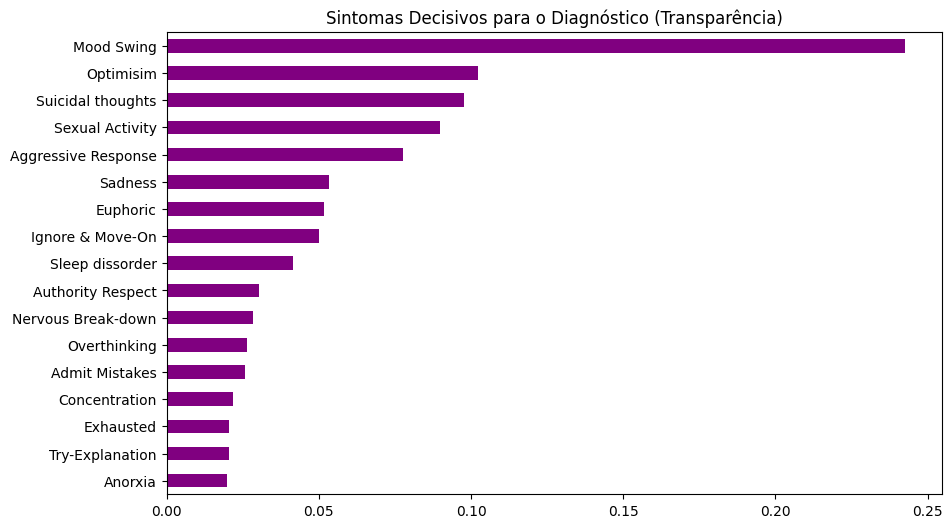

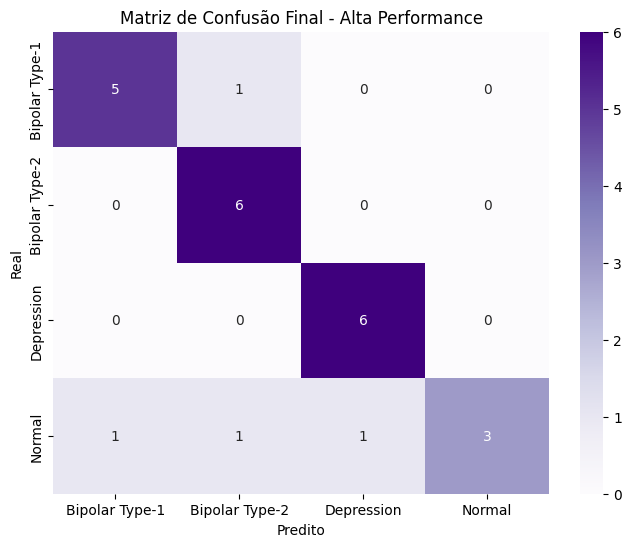

Modelo e Encoder salvos em /src/!


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib
import shap 

# 1. Carga de Dados
df = pd.read_csv('../data/Dataset-Mental-Disorders.csv')
X = df.drop(['Patient Number', 'Expert Diagnose'], axis=1)
y = df['Expert Diagnose']

# 2. Encoding Profissional
le = LabelEncoder()
for col in X.columns:
    X[col] = le.fit_transform(X[col])
y = le.fit_transform(y)
target_names = le.classes_

# 3. Divisão Estratificada (Mantém a proporção real das doenças)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Balanceamento Ético (SMOTE)
# Evita que o modelo ignore doenças raras (como Bipolar Tipo 1)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 5. Hyperparameter Tuning (Busca da Acurácia Máxima)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

print("Iniciando busca exaustiva (GridSearch)...")
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_res, y_train_res)

best_model = grid_search.best_estimator_

# --- VALIDAÇÃO DE CONFIANÇA ---

# 6. Acurácia Média Real (Cross-Validation no set completo balanceado)
cv_scores = cross_val_score(best_model, X_train_res, y_train_res, cv=10)
acuracia_media = cv_scores.mean()

# 7. Predição e Relatório
y_pred = best_model.predict(X_test)

print("-" * 30)
print(f"ACURÁCIA MÉDIA REAL (10-Fold CV): {acuracia_media:.2f}")
print(f"MELHORES PARÂMETROS: {grid_search.best_params_}")
print("-" * 30)
print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ÉTICO ===")
print(classification_report(y_test, y_pred, target_names=target_names))

# --- ANÁLISE DE ÉTICA E IMPORTÂNCIA ---

# 8. Gráfico de Feature Importance (Quais sintomas o modelo mais usa?)
plt.figure(figsize=(10, 6))
importancias = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
importancias.plot(kind='barh', color='purple')
plt.title('Sintomas Decisivos para o Diagnóstico (Transparência)')
plt.show()

# 9. Matriz de Confusão Final
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', 
            xticklabels=target_names, yticklabels=target_names, cmap='Purples')
plt.title('Matriz de Confusão Final - Alta Performance')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

# 10. Salvando o progresso
joblib.dump(best_model, '../src/modelo_final_mental.pkl')
joblib.dump(le, '../src/label_encoder.pkl')
print("Modelo e Encoder salvos em /src/!")